# K-Nearest Neighbors (Horse Survival Prediction)

## Penjelasan

### Tujuan

Membuat model machine learning yang dapat memprediksi kondisi kesehatan kuda, menggunakan algoritma K-Nearest Neighbors (KNN)

### Penjelasan Kolom

- ***surgery***: 1 = Yes, it had surgery 2 = It was treated without surgery
- ***age***: 1 = Adult horse 2 = Young (< 6 months)

## A. Data Preparation

### A.1 Import Libraries

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

### A.2 Load Data

In [175]:
try:
    df_train = pd.read_csv('train.csv')
    df_test = pd.read_csv('test.csv')
    print('Berhasil Membaca Data')
except Exception as e:
    print('Gagal Membaca Data')

Berhasil Membaca Data


### A.3 Melihat Dimensi Data

In [176]:
print(f'Dimensi Data Train: {df_train.shape}')
print(f'Dimensi Data Test: {df_test.shape}')

Dimensi Data Train: (1235, 29)
Dimensi Data Test: (824, 28)


### A.4 Melihat Informasi Data

In [177]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1235 non-null   int64  
 1   surgery                1235 non-null   object 
 2   age                    1235 non-null   object 
 3   hospital_number        1235 non-null   int64  
 4   rectal_temp            1235 non-null   float64
 5   pulse                  1235 non-null   float64
 6   respiratory_rate       1235 non-null   float64
 7   temp_of_extremities    1196 non-null   object 
 8   peripheral_pulse       1175 non-null   object 
 9   mucous_membrane        1214 non-null   object 
 10  capillary_refill_time  1229 non-null   object 
 11  pain                   1191 non-null   object 
 12  peristalsis            1215 non-null   object 
 13  abdominal_distention   1212 non-null   object 
 14  nasogastric_tube       1155 non-null   object 
 15  naso

In [178]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824 entries, 0 to 823
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     824 non-null    int64  
 1   surgery                824 non-null    object 
 2   age                    824 non-null    object 
 3   hospital_number        824 non-null    int64  
 4   rectal_temp            824 non-null    float64
 5   pulse                  824 non-null    float64
 6   respiratory_rate       824 non-null    float64
 7   temp_of_extremities    789 non-null    object 
 8   peripheral_pulse       777 non-null    object 
 9   mucous_membrane        811 non-null    object 
 10  capillary_refill_time  818 non-null    object 
 11  pain                   795 non-null    object 
 12  peristalsis            805 non-null    object 
 13  abdominal_distention   802 non-null    object 
 14  nasogastric_tube       760 non-null    object 
 15  nasoga

### A.5 Melihat Statistik Data

In [179]:
df_train.describe().T.style.format('{:.2f}').background_gradient(cmap='flare')

,count,mean,std,min,25%,50%,75%,max
id,1235.00,617.00,356.66,0.00,308.50,617.00,925.50,1234.00
hospital_number,1235.00,954500.40,1356403.14,521399.00,528800.00,529777.00,534145.00,5305129.00
rectal_temp,1235.00,38.20,0.79,35.40,37.80,38.20,38.60,40.80
pulse,1235.00,79.57,29.11,30.00,53.00,76.00,100.00,184.00
respiratory_rate,1235.00,30.05,16.45,8.00,18.00,28.00,36.00,96.00
nasogastric_reflux_ph,1235.00,4.38,1.94,1.00,2.00,4.50,6.00,7.50
packed_cell_volume,1235.00,49.60,10.54,23.00,43.00,48.00,57.00,75.00
total_protein,1235.00,21.39,26.68,3.50,6.60,7.50,9.10,89.00
abdomo_protein,1235.00,3.29,1.59,0.10,2.00,3.00,4.30,10.10
lesion_1,1235.00,3832.50,5436.73,0.00,2205.00,2209.00,3205.00,41110.00


### A.6 Melihat 5 Data Teratas dan 5 Data Terbawah

In [180]:
df_train.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,0,yes,adult,530001,38.1,132.0,24.0,cool,reduced,dark_cyanotic,more_3_sec,depressed,absent,slight,slight,less_1_liter,6.5,decreased,distend_small,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,1,yes,adult,533836,37.5,88.0,12.0,cool,normal,pale_cyanotic,more_3_sec,mild_pain,absent,moderate,none,more_1_liter,2.0,absent,distend_small,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,2,yes,adult,529812,38.3,120.0,28.0,cool,reduced,pale_pink,less_3_sec,extreme_pain,hypomotile,moderate,slight,none,3.5,NaN,distend_large,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,3,yes,adult,5262541,37.1,72.0,30.0,cold,reduced,pale_pink,more_3_sec,mild_pain,hypomotile,moderate,slight,more_1_liter,2.0,decreased,distend_small,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,4,no,adult,5299629,38.0,52.0,48.0,normal,normal,normal_pink,less_3_sec,alert,hypomotile,none,slight,less_1_liter,7.0,normal,normal,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


In [181]:
df_train.tail()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
1230,1230,yes,adult,535246,38.5,129.0,48.0,cool,reduced,pale_pink,more_3_sec,depressed,absent,moderate,none,more_1_liter,2.0,NaN,distend_large,57.0,66.0,serosanguious,2.0,yes,2206,0,0,no,lived
1231,1231,yes,adult,528570,37.5,60.0,50.0,cool,reduced,pale_cyanotic,less_3_sec,mild_pain,hypomotile,slight,slight,none,3.0,decreased,distend_small,35.0,6.4,serosanguious,3.6,yes,2209,0,0,yes,died
1232,1232,yes,young,529685,37.5,84.0,40.0,normal,reduced,normal_pink,less_3_sec,mild_pain,hypomotile,slight,slight,none,3.0,increased,firm,40.0,5.9,cloudy,7.0,yes,400,0,0,yes,lived
1233,1233,yes,adult,534784,38.1,70.0,16.0,normal,reduced,bright_red,less_3_sec,mild_pain,hypomotile,slight,none,more_1_liter,2.0,absent,distend_small,58.0,74.0,cloudy,2.0,yes,2209,0,0,no,lived
1234,1234,yes,adult,528548,38.1,54.0,36.0,normal,normal,pale_pink,less_3_sec,mild_pain,absent,none,slight,none,3.0,NaN,distend_small,45.0,6.0,clear,3.6,yes,2124,0,0,yes,lived


In [182]:
df_test.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,1235,no,adult,534053,38.6,40.0,20.0,normal,normal,normal_pink,less_3_sec,mild_pain,hypomotile,slight,none,none,7.0,normal,distend_small,42.0,7.5,clear,2.3,no,0,0,0,no
1,1236,yes,adult,528469,38.2,112.0,48.0,cool,reduced,bright_pink,more_3_sec,depressed,hypomotile,moderate,slight,none,3.5,decreased,distend_small,44.0,6.0,serosanguious,2.6,no,2208,0,0,yes
2,1237,yes,adult,528178,37.7,66.0,12.0,cool,normal,bright_red,less_3_sec,mild_pain,hypomotile,slight,slight,none,3.0,normal,distend_small,31.5,6.0,cloudy,1.6,yes,2205,0,0,yes
3,1238,no,adult,534784,37.1,88.0,20.0,cool,reduced,pale_cyanotic,less_3_sec,depressed,absent,severe,slight,more_1_liter,2.0,absent,distend_large,75.0,81.0,NaN,1.0,yes,1400,0,0,no
4,1239,yes,adult,529840,38.3,50.0,12.0,NaN,normal,bright_pink,less_3_sec,mild_pain,absent,slight,slight,none,3.0,decreased,distend_small,37.0,6.8,cloudy,2.6,yes,2208,0,0,yes


In [183]:
df_test.tail()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
819,2054,no,adult,529461,40.3,114.0,36.0,cool,reduced,normal_pink,more_3_sec,depressed,hypomotile,moderate,NaN,none,7.0,normal,distend_large,57.0,8.1,serosanguious,4.5,yes,3205,0,0,yes
820,2055,yes,adult,535338,37.2,100.0,20.0,cool,reduced,pale_cyanotic,more_3_sec,extreme_pain,absent,moderate,slight,more_1_liter,2.0,absent,distend_small,50.0,66.0,serosanguious,2.0,yes,2209,0,0,no
821,2056,yes,adult,529640,39.2,132.0,12.0,cool,reduced,dark_cyanotic,more_3_sec,depressed,hypomotile,moderate,slight,more_1_liter,6.5,decreased,NaN,53.0,7.6,serosanguious,4.5,yes,2205,0,0,no
822,2057,no,adult,5287179,38.3,54.0,66.0,normal,normal,normal_pink,less_3_sec,mild_pain,hypomotile,none,slight,none,7.0,normal,NaN,49.0,8.6,clear,5.0,no,3111,0,0,yes
823,2058,yes,adult,528461,38.1,66.0,12.0,cold,normal,normal_pink,less_3_sec,mild_pain,hypomotile,slight,slight,more_1_liter,2.0,absent,distend_small,31.5,6.2,NaN,1.6,yes,2205,0,0,yes


### A.7 Melihat Data Duplikat

In [184]:
print(df_train.duplicated().sum())
print(df_test.duplicated().sum())

0
0


### A.8 Melihat Data Hilang

In [185]:
print(df_train.isna().sum())
print(df_test.isna().sum())

id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
pulse                      0
respiratory_rate           0
temp_of_extremities       39
peripheral_pulse          60
mucous_membrane           21
capillary_refill_time      6
pain                      44
peristalsis               20
abdominal_distention      23
nasogastric_tube          80
nasogastric_reflux        21
nasogastric_reflux_ph      0
rectal_exam_feces        190
abdomen                  213
packed_cell_volume         0
total_protein              0
abdomo_appearance         48
abdomo_protein             0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
outcome                    0
dtype: int64
id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
p

Karena terdapat data hilang dari kedua dataframe, kami memutuskan untuk mengisi data hilang menggunakan Mean & Mode

In [186]:
## Kolom Numeric Diisi Rata-Rata (Mean)
for cols in df_train.select_dtypes(include=['number']).columns:
    df_train[cols] = df_train[cols].fillna(df_train[cols].mean())
    
## Kolom Object Diisi Kata Yang Sering Muncul (Modus/Mode)
for cols in df_train.select_dtypes(include=['object']).columns:
    df_train[cols] = df_train[cols].fillna(df_train[cols].mode()[0])

In [187]:
## Kolom Numeric Diisi Rata-Rata (Mean)
for cols in df_test.select_dtypes(include=['number']).columns:
    df_test[cols] = df_test[cols].fillna(df_test[cols].mean())

## Kolom Object Diisi Kata Yang Sering Muncul (Modus/Mode)
for cols in df_test.select_dtypes(include=['object']).columns:
    df_test[cols] = df_test[cols].fillna(df_test[cols].mode()[0])

In [188]:
print(df_train.isna().sum())
print(df_test.isna().sum())

id                       0
surgery                  0
age                      0
hospital_number          0
rectal_temp              0
pulse                    0
respiratory_rate         0
temp_of_extremities      0
peripheral_pulse         0
mucous_membrane          0
capillary_refill_time    0
pain                     0
peristalsis              0
abdominal_distention     0
nasogastric_tube         0
nasogastric_reflux       0
nasogastric_reflux_ph    0
rectal_exam_feces        0
abdomen                  0
packed_cell_volume       0
total_protein            0
abdomo_appearance        0
abdomo_protein           0
surgical_lesion          0
lesion_1                 0
lesion_2                 0
lesion_3                 0
cp_data                  0
outcome                  0
dtype: int64
id                       0
surgery                  0
age                      0
hospital_number          0
rectal_temp              0
pulse                    0
respiratory_rate         0
temp_of_extremi

## B. Data Preprocessing

### B.1 Menghapus Kolom Yang Tidak Berkorelasi

In [189]:
df_train.columns

Index(['id', 'surgery', 'age', 'hospital_number', 'rectal_temp', 'pulse',
       'respiratory_rate', 'temp_of_extremities', 'peripheral_pulse',
       'mucous_membrane', 'capillary_refill_time', 'pain', 'peristalsis',
       'abdominal_distention', 'nasogastric_tube', 'nasogastric_reflux',
       'nasogastric_reflux_ph', 'rectal_exam_feces', 'abdomen',
       'packed_cell_volume', 'total_protein', 'abdomo_appearance',
       'abdomo_protein', 'surgical_lesion', 'lesion_1', 'lesion_2', 'lesion_3',
       'cp_data', 'outcome'],
      dtype='object')

In [190]:
df_train.drop(columns=['id', 'hospital_number'], inplace=True)
df_test.drop(columns=['id', 'hospital_number'], inplace=True)

### B.2 Mengatasi Outliers

In [191]:
num = df_train.select_dtypes(include='number')
for col in num:
    Q1 =  df_train[col].quantile(0.25)
    Q3 =  df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    if IQR > 0:
        low_b = Q1 - IQR * 1.5
        upp_b = Q3 + IQR * 1.5
        
        df_train_clean = df_train[(df_train[col] > low_b) & (df_train[col] < upp_b)]

In [192]:
print(f'Data Train Sebelum Handling Outliers: {df_train.shape}')
print(f'Data Train Setelah Handling Outliers: {df_train_clean.shape}')

Data Train Sebelum Handling Outliers: (1235, 27)
Data Train Setelah Handling Outliers: (929, 27)


In [193]:
num = df_test.select_dtypes(include='number')
for col in num:
    Q1 =  df_test[col].quantile(0.25)
    Q3 =  df_test[col].quantile(0.75)
    IQR = Q3 - Q1
    
    if IQR > 0:
        low_b = Q1 - IQR * 1.5
        upp_b = Q3 + IQR * 1.5
        
        df_test_clean = df_test[(df_test[col] > low_b) & (df_test[col] < upp_b)]

In [194]:
print(f'Data Test Sebelum Handling Outliers: {df_test.shape}')
print(f'Data Test Setelah Handling Outliers: {df_test_clean.shape}')

Data Test Sebelum Handling Outliers: (824, 26)
Data Test Setelah Handling Outliers: (608, 26)


### B.3 Mapping Fitur & Target (Object Columns)

In [195]:
df_train_map = df_train.copy()
df_train_clean_map = df_train.copy()

In [196]:
for cols in df_train.select_dtypes(include='object'):
    df_train_map[cols] = df_train[cols].astype('category').cat.codes
    df_train_clean_map[cols] = df_train[cols].astype('category').cat.codes

df_train_map.head()

,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,1,0,38.1,132.0,24.0,1,3,2,2,1,0,3,2,0,6.5,1,1,57.0,8.5,2,3.4,1,2209,0,0,0,0
1,1,0,37.5,88.0,12.0,1,2,4,2,3,0,0,0,1,2.0,0,1,33.0,64.0,2,2.0,1,2208,0,0,0,1
2,1,0,38.3,120.0,28.0,1,3,5,1,2,3,0,2,2,3.5,0,0,37.0,6.4,2,3.4,1,5124,0,0,0,2
3,1,0,37.1,72.0,30.0,0,3,5,2,3,3,0,2,1,2.0,1,1,53.0,7.0,1,3.9,1,2208,0,0,1,2
4,0,0,38.0,52.0,48.0,2,2,3,1,0,3,1,2,0,7.0,3,3,47.0,7.3,1,2.6,0,0,0,0,1,2


In [197]:
df_train.head()

,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,peristalsis,abdominal_distention,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,yes,adult,38.1,132.0,24.0,cool,reduced,dark_cyanotic,more_3_sec,depressed,absent,slight,slight,less_1_liter,6.5,decreased,distend_small,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,yes,adult,37.5,88.0,12.0,cool,normal,pale_cyanotic,more_3_sec,mild_pain,absent,moderate,none,more_1_liter,2.0,absent,distend_small,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,yes,adult,38.3,120.0,28.0,cool,reduced,pale_pink,less_3_sec,extreme_pain,hypomotile,moderate,slight,none,3.5,absent,distend_large,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,yes,adult,37.1,72.0,30.0,cold,reduced,pale_pink,more_3_sec,mild_pain,hypomotile,moderate,slight,more_1_liter,2.0,decreased,distend_small,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,no,adult,38.0,52.0,48.0,normal,normal,normal_pink,less_3_sec,alert,hypomotile,none,slight,less_1_liter,7.0,normal,normal,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


## C. Exploratory Data Analysis

## D. Modelling

### D.1 Mendefinisikan Variabel X (Fitur) dan y (Target)

In [198]:
X_data = df_train_map.drop(columns=['outcome'])
y_data = df_train_map['outcome']

### D.2 Split Data Train & Test (80 : 20)

In [199]:
def stratified_split(X_data, y_data, train_size=0.8, random_state=42):
    np.random.seed(42)
    
    X_train_list, X_test_list = [], []
    y_train_list, y_test_list = [], []
    
    for class_value in np.unique(y_data):
        class_idx = np.where(y_data == class_value)[0]
        
        idx = np.random.permutation(class_idx)
        split_ratio = int(len(idx) * train_size)
        
        X_train_list.append(X_data.iloc[idx[:split_ratio]])    
        X_test_list.append(X_data.iloc[idx[split_ratio:]])    
        y_train_list.append(y_data.iloc[idx[:split_ratio]])    
        y_test_list.append(y_data.iloc[idx[split_ratio:]])   
        
    X_train = pd.concat(X_train_list).reset_index(drop=True) 
    X_test = pd.concat(X_test_list).reset_index(drop=True) 
    y_train = pd.concat(y_train_list).reset_index(drop=True) 
    y_test = pd.concat(y_test_list).reset_index(drop=True)
    
    return X_train, X_test, y_train, y_test

In [200]:
X_train, X_test, y_train, y_test = stratified_split(X_data, y_data)

In [201]:
print(f"Total Train Data: {X_train.shape}")
print(f"Total Test Data: {X_test.shape}")

Total Train Data: (987, 26)
Total Test Data: (248, 26)


### D.3 Feature Scaling

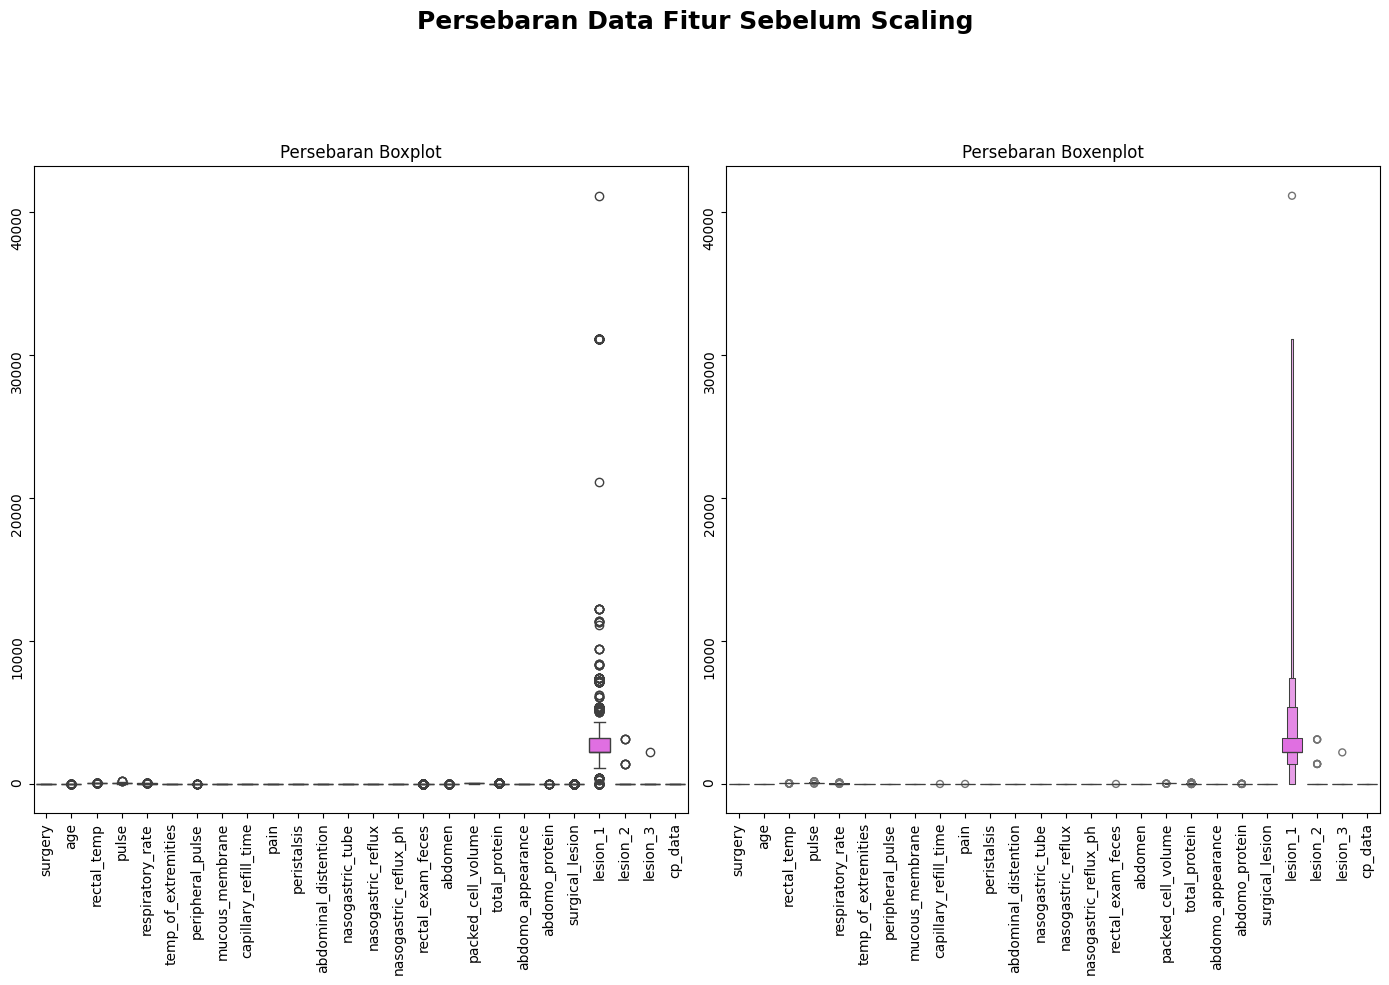

In [202]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

sns.boxplot(X_train, ax=axes[0])
axes[0].set_title('Persebaran Boxplot')
axes[0].tick_params(rotation=90)

sns.boxenplot(X_train, ax=axes[1])
axes[1].set_title('Persebaran Boxenplot')
axes[1].tick_params(rotation=90)

plt.suptitle('Persebaran Data Fitur Sebelum Scaling', fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

#### Standard Scale


In [203]:
X_train_mean = X_train.mean()
X_train_std = X_train.std()

X_train_standard_scale = (X_train - X_train_mean) / X_train_std
X_test_standard_scale = (X_test - X_train_mean) / X_train_std

#### MinMax Scale (Normalization)

In [204]:
X_train_max = X_train.max()
X_train_min = X_train.min()

X_train_minmax_scale = (X_train - X_train_min) / (X_train_max - X_train_min)
X_test_minmax_scale = (X_test - X_train_min) / (X_train_max - X_train_min)

#### Robust Scale

In [205]:
median = X_train.median(axis=0)
Q1 = X_train.quantile(0.25, axis=0)
Q3 = X_train.quantile(0.75, axis=0)
IQR = Q3 - Q1

IQR[IQR == 0] = 1
X_train_robust_scale = (X_train - median) / IQR
X_test_robust_scale = (X_test - median) / IQR

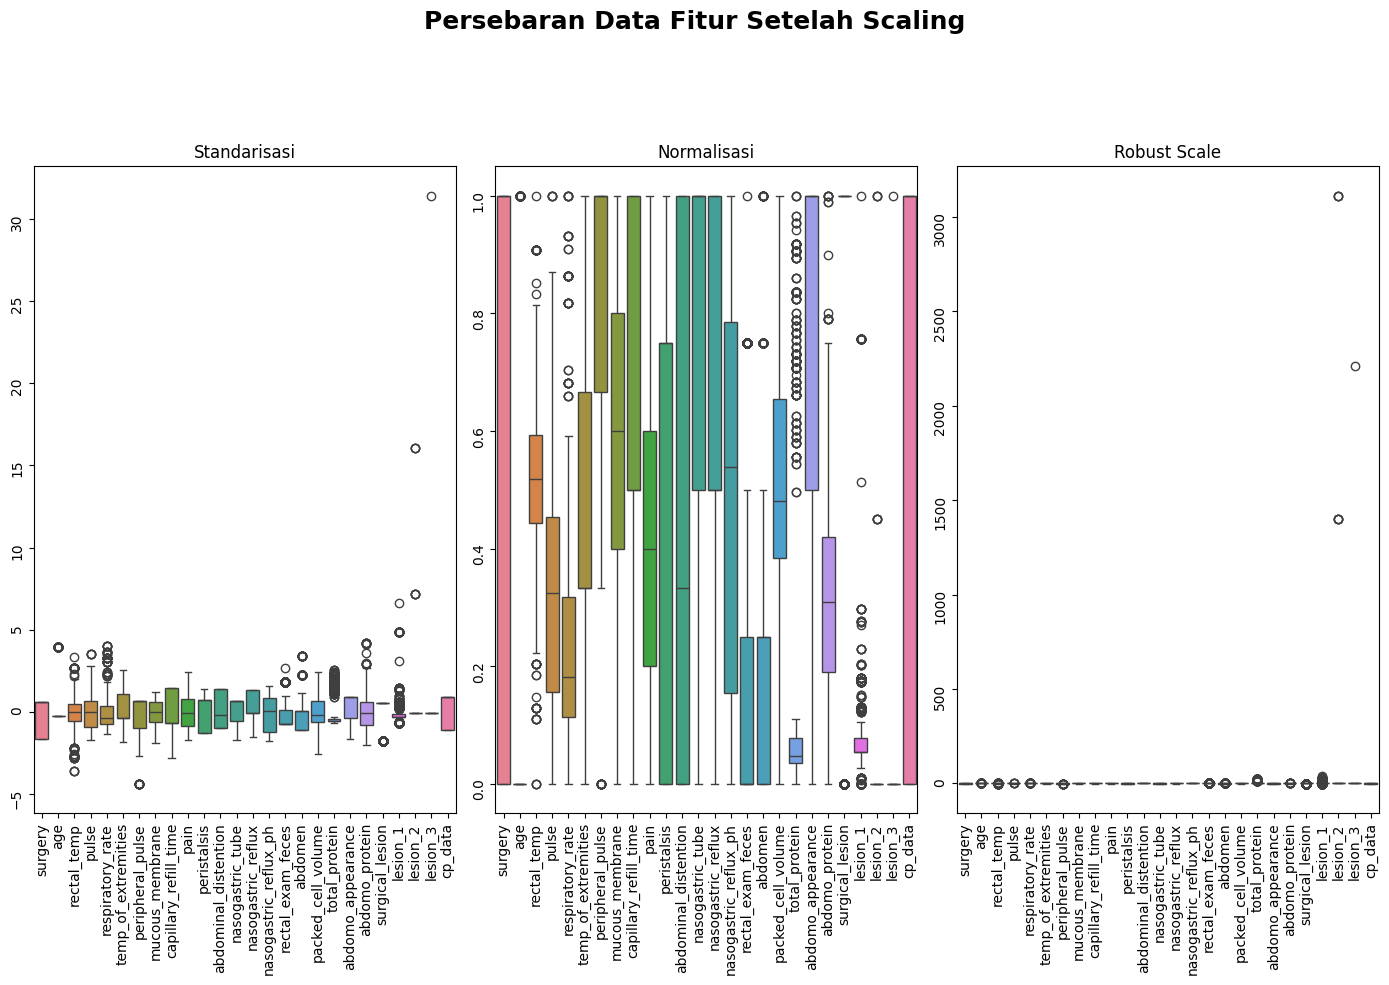

In [206]:
fig, axes = plt.subplots(1, 3, figsize=(14, 10))

sns.boxplot(X_train_standard_scale, ax=axes[0])
axes[0].set_title('Standarisasi')
axes[0].tick_params(rotation=90)

sns.boxplot(X_train_minmax_scale, ax=axes[1])
axes[1].set_title('Normalisasi')
axes[1].tick_params(rotation=90)

sns.boxplot(X_train_robust_scale, ax=axes[2])
axes[2].set_title('Robust Scale')
axes[2].tick_params(rotation=90)

plt.suptitle('Persebaran Data Fitur Setelah Scaling', fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

### D.4 K-Nearest Neighbors

In [207]:
class KNN:
    def __init__(self, k, p, weights):
        self.P = p
        self.K = k
        self.Weights = weights
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def distance(self, x1, x2):
        diff = np.abs(x1 - x2)
        axis_val = 1 if x1.ndim > 1 else 0
        
        if self.P == 1:
            return np.sum(diff, axis=axis_val)
        elif self.P == 2:
            return np.sqrt(np.sum(diff ** 2, axis=axis_val))
        elif self.P == float('inf') or self.P == 'chebyshev':
            return np.max(diff, axis=axis_val)
        else:
            return np.power(np.sum(diff ** self.P, axis=axis_val), 1/self.P)
        
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)
    
    def _predict(self, x):
        dists = self.distance(self.X_train, x)
        best_k = np.argsort(dists)[:self.K]
        label_k = self.y_train[best_k]
        
        if self.Weights == 'uniform':
            values, counts = np.unique(label_k, return_counts=True)
            return values[np.argmax(counts)]
        
        elif self.Weights == 'distance':
            weights = 1 / (dists[best_k] + 1e-6)
            vote_scores = {}
            
            for label, weight in zip(label_k, weights):
                vote_scores[label] = vote_scores.get(label, 0) + weight
            return max(vote_scores, key=vote_scores.get)
        

### D.5 Grid Search (Mencari K, Jarak, dan Metric Optimal)

#### Grid Search Test Predictions

In [208]:
print("|   K   |   Jarak   |  Accuracy  |    Weights    |")

best_acc = 0
best_params = {}

for k in [3, 5, 7, 9, 11, 13, 15]:
    for p in [1, 2, 'chebyshev']:
        for w in ['uniform', 'distance']:
            model = KNN(k, p, w)
            model.fit(X_train_robust_scale.values, y_train.values)
            pred = model.predict(X_test_robust_scale.values)
            acc = np.mean(pred == y_test.values)
            
            if p == 1:
                dist = 'Manhattan'
            elif p == 2:
                dist = 'Euclidean'
            else:
                dist = 'Chebyshev'
                
            print(f'|   {k}   | {dist} |    {acc:.2f}    |    {w}    |')
            if acc > best_acc:
                best_acc = acc
                best_params = {'k': k, 'p' : p, 'w' : w}
                
if best_params['p'] == 1:
    dist_name = 'Manhattan'
elif best_params['p'] == 2:
    dist_name = 'Euclidean'
else:
    dist_name = 'Chebyshev'
    
print(f"Best K: {best_params['k']} | Best Distance: {dist_name}  | Best Metric: {best_params['w']}  | Best Acc: {best_acc:.3f}")

|   K   |   Jarak   |  Accuracy  |    Weights    |
|   3   | Manhattan |    0.61    |    uniform    |
|   3   | Manhattan |    0.61    |    distance    |
|   3   | Euclidean |    0.56    |    uniform    |
|   3   | Euclidean |    0.54    |    distance    |
|   3   | Chebyshev |    0.55    |    uniform    |
|   3   | Chebyshev |    0.52    |    distance    |
|   5   | Manhattan |    0.65    |    uniform    |
|   5   | Manhattan |    0.64    |    distance    |
|   5   | Euclidean |    0.58    |    uniform    |
|   5   | Euclidean |    0.58    |    distance    |
|   5   | Chebyshev |    0.56    |    uniform    |
|   5   | Chebyshev |    0.54    |    distance    |
|   7   | Manhattan |    0.67    |    uniform    |
|   7   | Manhattan |    0.64    |    distance    |
|   7   | Euclidean |    0.58    |    uniform    |
|   7   | Euclidean |    0.58    |    distance    |
|   7   | Chebyshev |    0.54    |    uniform    |
|   7   | Chebyshev |    0.50    |    distance    |
|   9   | Manhattan | 

#### Grid Search Train Predictions

In [209]:
print("|   K   |   Jarak   |  Accuracy  |    Weights    |")

best_acc = 0
best_params = {}

for k in [3, 5, 7, 9, 11, 13, 15]:
    for p in [1, 2, 'chebyshev']:
        for w in ['uniform', 'distance']:
            model = KNN(k, p, w)
            model.fit(X_train_robust_scale.values, y_train.values)
            pred = model.predict(X_train_robust_scale.values)
            acc = np.mean(pred == y_train.values)
            
            if p == 1:
                dist = 'Manhattan'
            elif p == 2:
                dist = 'Euclidean'
            else:
                dist = 'Chebyshev'
                
            print(f'|   {k}   | {dist} |    {acc:.2f}    |    {w}    |')
            if acc > best_acc:
                best_acc = acc
                best_params = {'k': k, 'p' : p, 'w' : w}
                
if best_params['p'] == 1:
    dist_name = 'Manhattan'
elif best_params['p'] == 2:
    dist_name = 'Euclidean'
else:
    dist_name = 'Chebyshev'
    
print(f"Best K: {best_params['k']} | Best Distance: {dist_name}  | Best Metric: {best_params['w']}  | Best Acc: {best_acc}")

|   K   |   Jarak   |  Accuracy  |    Weights    |
|   3   | Manhattan |    0.80    |    uniform    |
|   3   | Manhattan |    1.00    |    distance    |
|   3   | Euclidean |    0.80    |    uniform    |
|   3   | Euclidean |    1.00    |    distance    |
|   3   | Chebyshev |    0.75    |    uniform    |
|   3   | Chebyshev |    1.00    |    distance    |
|   5   | Manhattan |    0.76    |    uniform    |
|   5   | Manhattan |    1.00    |    distance    |
|   5   | Euclidean |    0.75    |    uniform    |
|   5   | Euclidean |    1.00    |    distance    |
|   5   | Chebyshev |    0.68    |    uniform    |
|   5   | Chebyshev |    1.00    |    distance    |
|   7   | Manhattan |    0.74    |    uniform    |
|   7   | Manhattan |    1.00    |    distance    |
|   7   | Euclidean |    0.74    |    uniform    |
|   7   | Euclidean |    1.00    |    distance    |
|   7   | Chebyshev |    0.66    |    uniform    |
|   7   | Chebyshev |    1.00    |    distance    |
|   9   | Manhattan | 

Setelah melakukan beberapa percobaan dan eksperimen Grid Search menggunakan kedua data (Test dan Train), kami mendapatkan kesimpulan sebagai berikut:

Test:
- Akurasi Maksimal = 65.7%
- Parameter = K: 9 | Distance: Manhattan | Metric: Distance |

Train:
- Akurasi Maksimal = 100%
- Parameter = K: 3 | Distance: Manhattan | Metric: Distance |

Note:
1. Menghapus Outlier / Membiarkan Outlier pada data tidak mengubah akurasi terbaik Grid Search
2. Metode Feature Scaling terbaik untuk data adalah 
    - Standard Scale = 65.7%
    - MinMax Scale = 64.5%
    - Robust Scale = 66.5%


### D.6 Elbow Method (Melihat Error Rate Model)

#### Error Rate Setiap Distance (Metric Uniform)

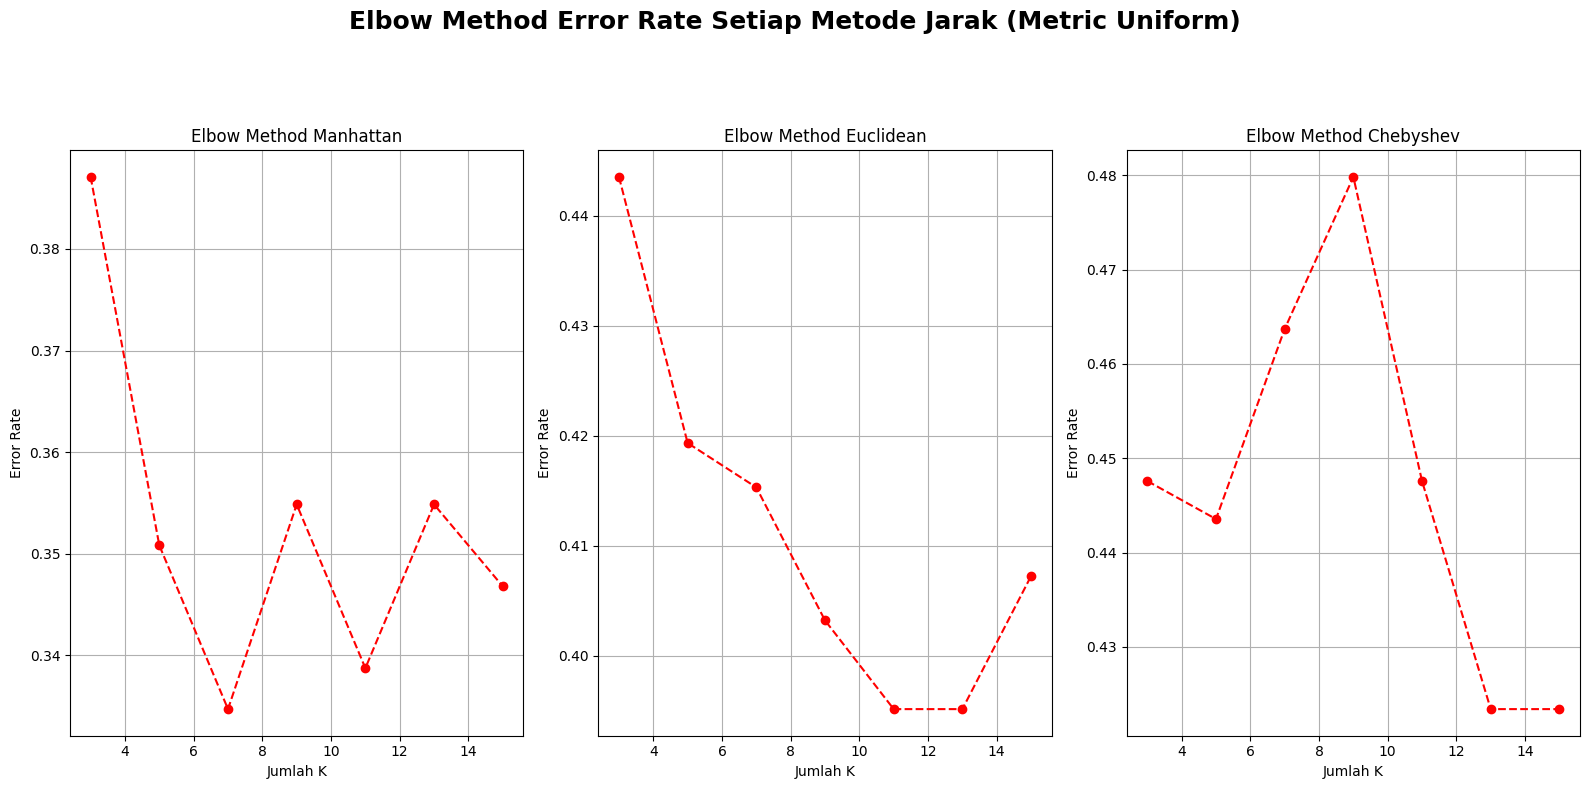

In [210]:
distances = [(1, "Manhattan"), (2, "Euclidean"), ('chebyshev', "Chebyshev")]
range_k = [3, 5, 7, 9, 11, 13, 15]

fig, axes = plt.subplots(1, 3, figsize=(16, 8))
for i, (p, name) in enumerate(distances):
    errors = []
    for k in range_k:
        model = KNN(k, p, 'uniform')
        model.fit(X_train_robust_scale.values, y_train)
        pred = model.predict(X_test_robust_scale.values)
        error = np.mean(pred != y_test.values)
        errors.append(error)
        
    axes[i].plot(range_k, errors, marker='o', linestyle='--', color='red')
    axes[i].set_title(f'Elbow Method {name}')
    axes[i].set_xlabel('Jumlah K')
    axes[i].set_ylabel('Error Rate')
    axes[i].grid(True)

plt.suptitle('Elbow Method Error Rate Setiap Metode Jarak (Metric Uniform)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()        

#### Error Rate Setiap Distance (Metric Distance)

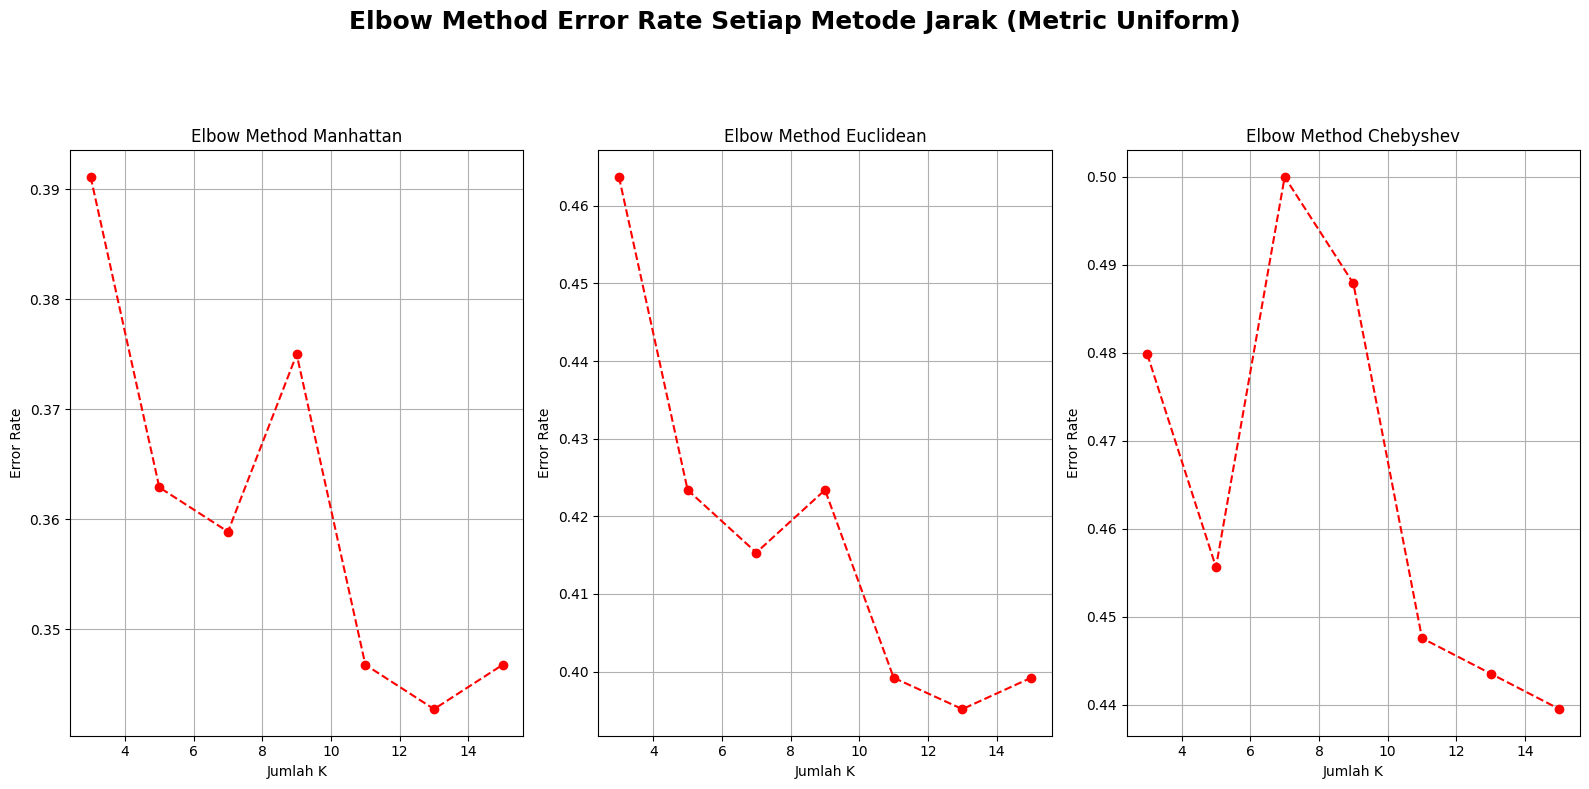

In [211]:
distances = [(1, "Manhattan"), (2, "Euclidean"), ('chebyshev', "Chebyshev")]
range_k = [3, 5, 7, 9, 11, 13, 15]

fig, axes = plt.subplots(1, 3, figsize=(16, 8))
for i, (p, name) in enumerate(distances):
    errors = []
    for k in range_k:
        model = KNN(k, p, 'distance')
        model.fit(X_train_robust_scale.values, y_train)
        pred = model.predict(X_test_robust_scale.values)
        error = np.mean(pred != y_test.values)
        errors.append(error)
        
    axes[i].plot(range_k, errors, marker='o', linestyle='--', color='red')
    axes[i].set_title(f'Elbow Method {name}')
    axes[i].set_xlabel('Jumlah K')
    axes[i].set_ylabel('Error Rate')
    axes[i].grid(True)

plt.suptitle('Elbow Method Error Rate Setiap Metode Jarak (Metric Uniform)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()  

Berdasarkan kedua grafik di atas, Manhattan Distance (Metric Uniform) memberikan error rate terendah dibanding Euclidean & Chebyshev. K=7 dipilih sebagai titik optimum karena memiliki error rate terendah.

### D.7 Validation Curve (Mencari Gap Optimal Antara Test dan Train)

#### Validation Curve Setiap Distance (Metric Uniform)

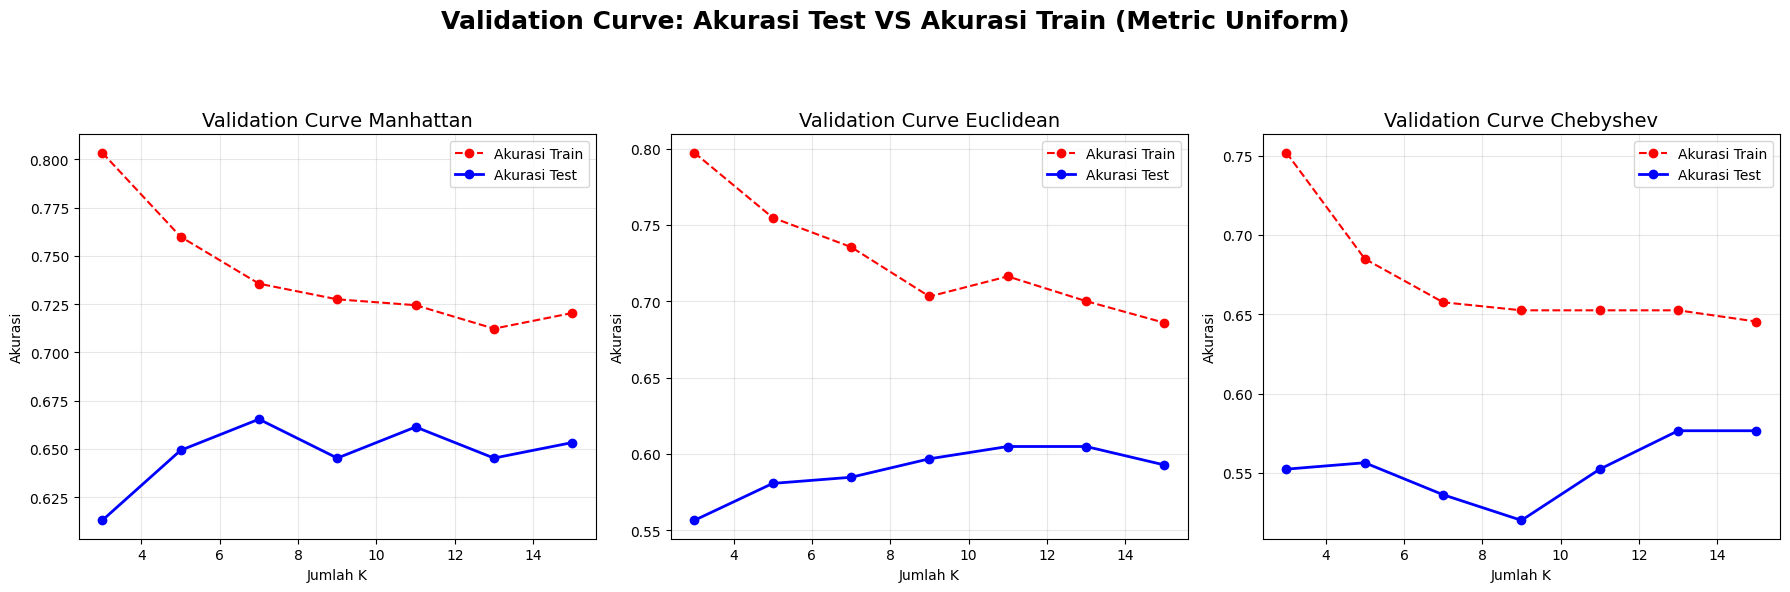

In [212]:
distances = [(1, "Manhattan"), (2, "Euclidean"), ('chebyshev', "Chebyshev")]
range_k = [3, 5, 7, 9, 11, 13, 15]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (p, name) in enumerate(distances):
    train_accuracies = []
    test_accuracies = []
    
    for k in range_k:
        model = KNN(k, p, 'uniform')
        model.fit(X_train_robust_scale.values, y_train.values)
        
        train_pred = model.predict(X_train_robust_scale.values)
        train_acc = np.mean(train_pred == y_train.values)
        train_accuracies.append(train_acc)
        
        test_pred = model.predict(X_test_robust_scale.values)
        test_acc = np.mean(test_pred == y_test.values)
        test_accuracies.append(test_acc)
        
    axes[i].plot(range_k, train_accuracies, marker='o', linestyle='--', color='red', label='Akurasi Train')
    axes[i].plot(range_k, test_accuracies, marker='o', linewidth=2, color='blue', label='Akurasi Test')
    
    axes[i].set_title(f'Validation Curve {name}', fontsize=14)
    axes[i].set_xlabel('Jumlah K')
    axes[i].set_ylabel('Akurasi')
    axes[i].legend()
    axes[i].grid(True, alpha = 0.3)
    
plt.suptitle('Validation Curve: Akurasi Test VS Akurasi Train (Metric Uniform)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

#### Validation Curve Setiap Distance (Metric Distance)

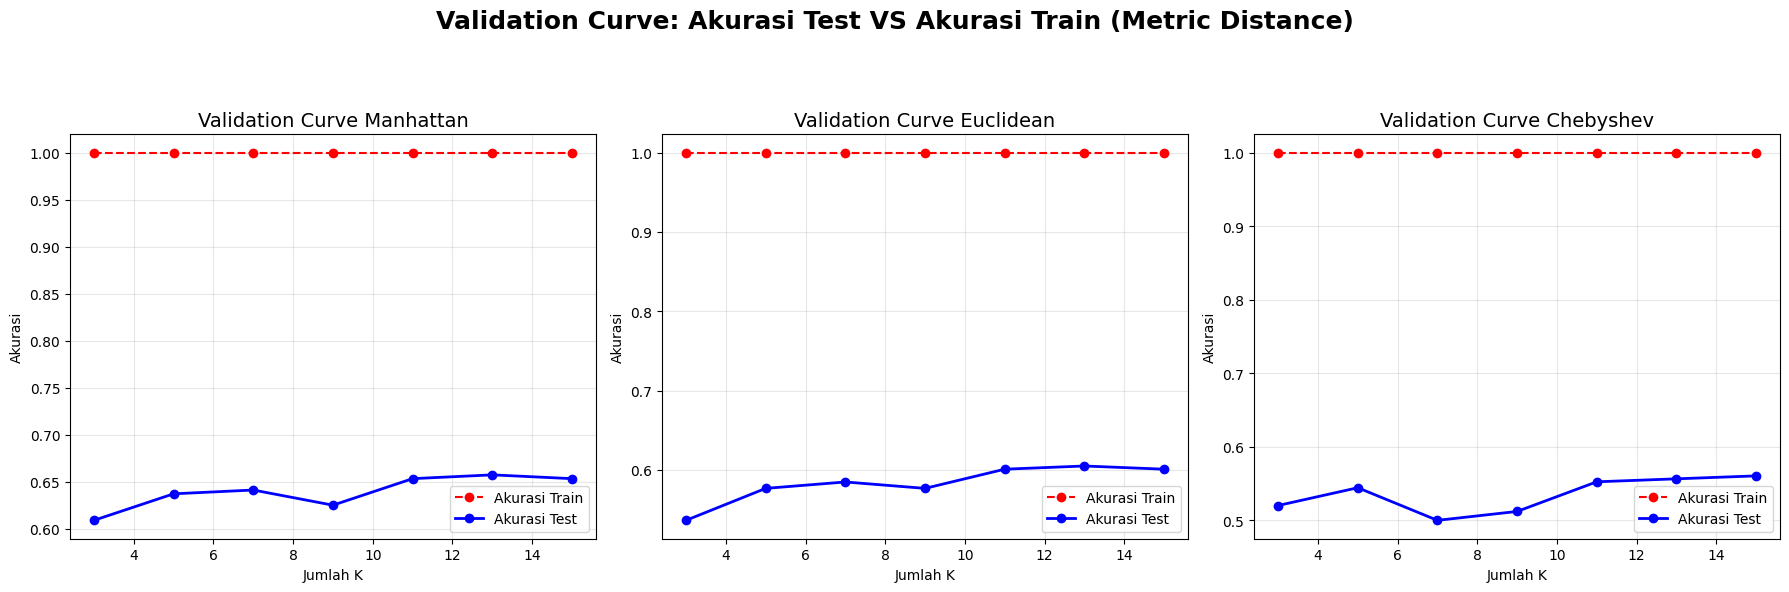

In [213]:
distances = [(1, "Manhattan"), (2, "Euclidean"), ('chebyshev', "Chebyshev")]
range_k = [3, 5, 7, 9, 11, 13, 15]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (p, name) in enumerate(distances):
    train_accuracies = []
    test_accuracies = []

    for k in range_k:
        model = KNN(k, p, 'distance')
        model.fit(X_train_robust_scale.values, y_train.values)
        
        train_pred = model.predict(X_train_robust_scale.values)
        train_acc = np.mean(train_pred == y_train.values)
        train_accuracies.append(train_acc)
        
        test_pred = model.predict(X_test_robust_scale.values)
        test_acc = np.mean(test_pred == y_test.values)
        test_accuracies.append(test_acc)
        
    axes[i].plot(range_k, train_accuracies, marker='o', linestyle='--', color='red', label='Akurasi Train')
    axes[i].plot(range_k, test_accuracies, marker='o', linewidth=2, color='blue', label='Akurasi Test')
    
    axes[i].set_title(f'Validation Curve {name}', fontsize=14)
    axes[i].set_xlabel('Jumlah K')
    axes[i].set_ylabel('Akurasi')
    axes[i].legend()
    axes[i].grid(True, alpha = 0.3)

plt.suptitle('Validation Curve: Akurasi Test VS Akurasi Train (Metric Distance)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

Berdasarkan kedua grafik di atas, Manhattan Distance (Metric Uniform) memberikan akurasi test tertinggi dibanding Euclidean & Chebyshev. K=11 dipilih sebagai titik optimum karena memiliki gap terkecil.

### D.8 Memprediksi Menggunakan Parameter Terbaik

In [214]:
model_fix = KNN(11, 1, 'uniform')
model_fix.fit(X_train_robust_scale.values, y_train.values)

test_predictions = model_fix.predict(X_test_robust_scale.values)
train_predictions = model_fix.predict(X_train_robust_scale.values)

## E. Evaluation

### E.1 Akurasi Model

#### Akurasi Test

In [215]:
test_accuracy = np.mean(test_predictions == y_test.values)
print(f'Accuracy (Test): {test_accuracy:.3f}')

Accuracy (Test): 0.661


#### Akurasi Train

In [216]:
train_accuracy = np.mean(train_predictions == y_train.values)
print(f'Accuracy (Train): {train_accuracy:.3f}')

Accuracy (Train): 0.724


### E.2 Confusion Matrix

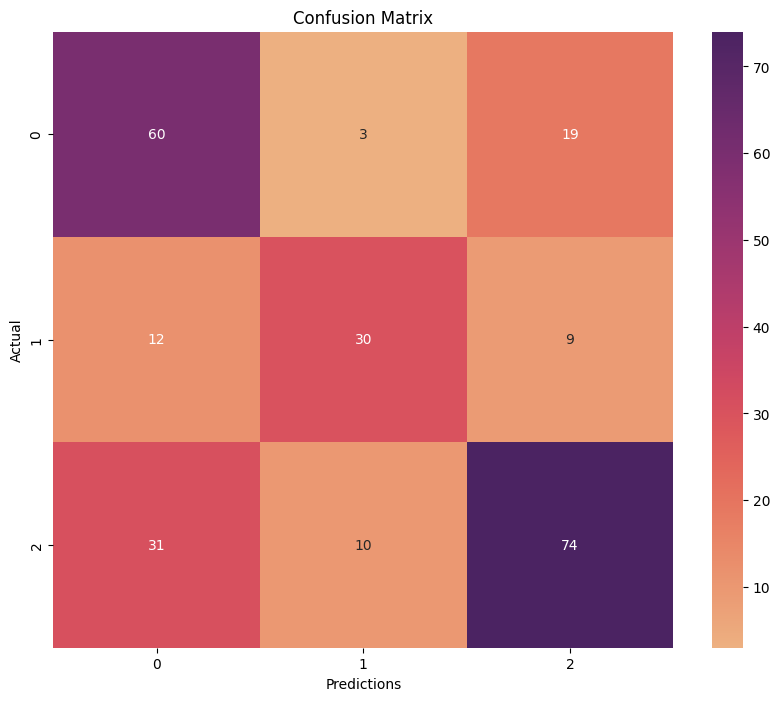

Class: Died
True Positives: 60
False Positives: 43
False Negatives: 22
True Negatives: 123

Class: Euthanized
True Positives: 30
False Positives: 13
False Negatives: 21
True Negatives: 184

Class: Lived
True Positives: 74
False Positives: 28
False Negatives: 41
True Negatives: 105



In [217]:
confusion_matrix = pd.crosstab(y_test, test_predictions, rownames=['Actual'], colnames=['Predictions'])
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix, annot=True, cmap='flare', fmt='d')
plt.title('Confusion Matrix')
plt.show()

cm_array = confusion_matrix.values
TP = np.diag(cm_array)
FP = np.sum(cm_array, axis=0) - TP
FN = np.sum(cm_array, axis=1) - TP
TN = np.sum(cm_array) - (TP + FP + FN)

class_names = confusion_matrix.columns
for i, name in enumerate(class_names):
    if name == 0:
        classes = 'Died'
    elif name == 1:
        classes = 'Euthanized'
    else:
        classes = 'Lived'
        
    print(f'Class: {classes}')
    print(f'True Positives: {TP[i]}')
    print(f'False Positives: {FP[i]}')
    print(f'False Negatives: {FN[i]}')
    print(f'True Negatives: {TN[i]}\n')

### E.3 Precision

In [218]:
precision = np.mean(TP / (TP + FP))
print(f'Precision: {precision:.2f}')

Precision: 0.67


### E.4 Recall

In [219]:
recall = np.mean(TP / (TP + FN))
print(f'Recall: {recall:.2f}')

Recall: 0.65


### E.5 F-1 Score

In [220]:
f1 = 2 * (precision * recall) / (precision + recall)
print(f'F1-Score: {f1:.2f}')

F1-Score: 0.66


### E.6 Prediksi Model (Visual)

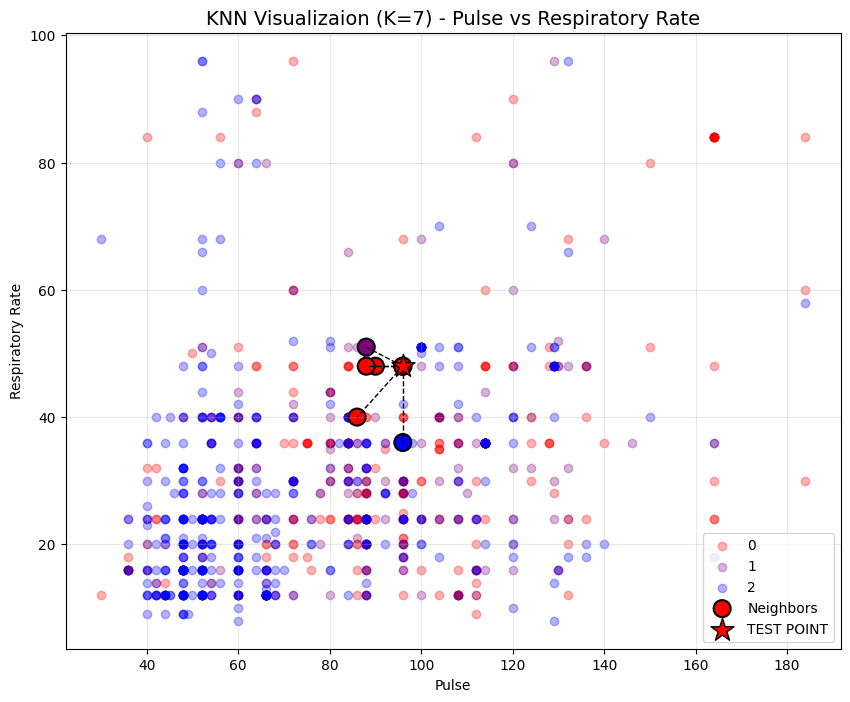

In [222]:
def visualize_knn_iris(X_train, y_train, test_data_point, k_neighbors=7):
    X_train_array = X_train.values
    y_train_array = y_train.values
    test_point_array = test_data_point.values

    feature_x_idx = 3
    feature_y_idx = 4
    species_colors = {
        0: 'red',
        1: 'purple',
        2: 'blue'
    }

    distances = np.sqrt(np.sum((X_train_array - test_point_array)**2, axis=1))
    nearest_indices = np.argsort(distances)[:k_neighbors]
    neighbors_X = X_train_array[nearest_indices]
    neighbors_y = y_train_array[nearest_indices]

    plt.figure(figsize=(10, 8))
    for species_name, color_code in species_colors.items():
        subset_data = X_train_array[y_train_array == species_name]
        plt.scatter(subset_data[:, feature_x_idx], subset_data[:, feature_y_idx], 
                    c=color_code, alpha=0.3, label=species_name)

    for i in range(k_neighbors):
        neighbor_x = neighbors_X[i, feature_x_idx]
        neighbor_y = neighbors_X[i, feature_y_idx]
        
        plt.plot([test_point_array[feature_x_idx], neighbor_x], 
                 [test_point_array[feature_y_idx], neighbor_y], 
                 color='black', linestyle='--', linewidth=1)

    neighbor_colors = [species_colors[y] for y in neighbors_y]
    plt.scatter(neighbors_X[:, feature_x_idx], neighbors_X[:, feature_y_idx], 
                c=neighbor_colors, s=150, edgecolor='black', linewidth=1.5, label='Neighbors')

    plt.scatter(test_point_array[feature_x_idx], test_point_array[feature_y_idx], 
                color='red', marker='*', s=300, edgecolor='black', label='TEST POINT', zorder=10)

    plt.title(f'KNN Visualizaion (K={k_neighbors}) - Pulse vs Respiratory Rate', fontsize=14)
    plt.xlabel('Pulse')
    plt.ylabel('Respiratory Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

sample_test = X_test.iloc[10] 

visualize_knn_iris(X_train, y_train, sample_test, k_neighbors=7)

### E.7 Evaluasi Model (Visual)

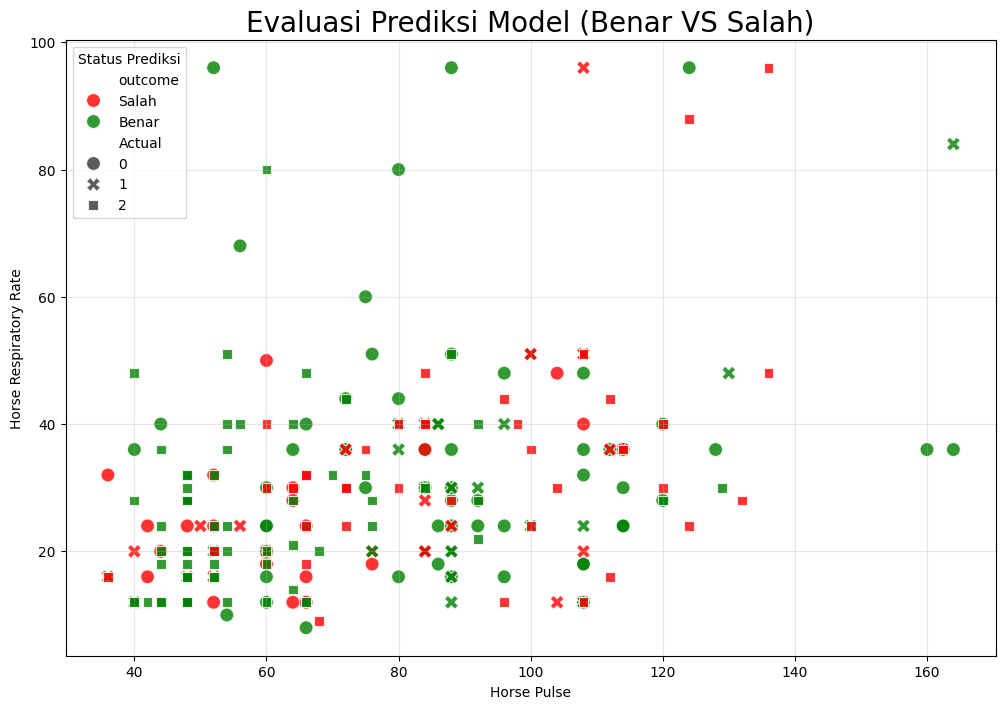

In [223]:
plot_data = pd.DataFrame({
    'Pulse' : X_test.iloc[:, 3],
    'Respiratory Rate' : X_test.iloc[:, 4],
    'Actual': y_test,
    'Prediction': test_predictions
})

plot_data['outcome'] = np.where(plot_data['Actual'] == plot_data['Prediction'], 'Benar', 'Salah')

plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_data, x='Pulse', y='Respiratory Rate', hue='outcome', style='Actual'
                , palette={'Benar' : 'green', 'Salah' : 'red'}, s=100, alpha=0.8)

plt.title('Evaluasi Prediksi Model (Benar VS Salah)', fontsize=20)
plt.xlabel('Horse Pulse')
plt.ylabel('Horse Respiratory Rate')
plt.legend(title='Status Prediksi')
plt.grid(True, alpha=0.3)
plt.show()

### E.8 ROC-AUC Visualization

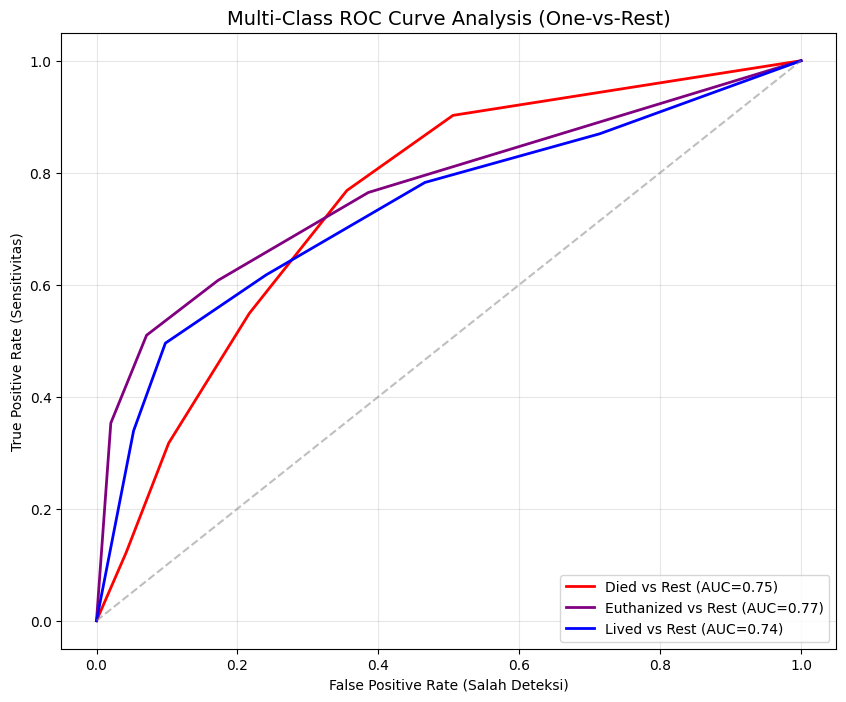

In [224]:
def get_probabilities(X_train, y_train, X_test, target_class, k=5):
    if hasattr(X_train, 'values'): X_train = X_train.values
    if hasattr(y_train, 'values'): y_train = y_train.values
    if hasattr(X_test, 'values'): X_test = X_test.values

    probs = []
    for row in X_test:
        dists = np.sqrt(np.sum((X_train - row)**2, axis=1))
        idx_neighbors = np.argsort(dists)[:k]
        labels_neighbors = y_train[idx_neighbors]
        prob = np.mean(labels_neighbors == target_class) 
        probs.append(prob)
        
    return np.array(probs)

plt.figure(figsize=(10, 8))
classes = [0, 1, 2]
colors = ['red', 'purple', 'blue']
class_names = ['Died', 'Euthanized', 'Lived']

for class_id, color, name in zip(classes, colors, class_names):
    y_test_binary = (y_test.values == class_id).astype(int)
    y_probs = get_probabilities(X_train, y_train, X_test, target_class=class_id, k=5)
    thresholds = np.linspace(0, 1.1, 20)
    tpr_list = []
    fpr_list = []
    
    P = np.sum(y_test_binary == 1)
    N = np.sum(y_test_binary == 0)
    
    for t in thresholds:
        y_pred_temp = (y_probs >= t).astype(int)
        TP = np.sum((y_pred_temp == 1) & (y_test_binary == 1))
        FP = np.sum((y_pred_temp == 1) & (y_test_binary == 0))
        
        tpr_list.append(TP / P if P > 0 else 0)
        fpr_list.append(FP / N if N > 0 else 0)
        
    auc_score = np.trapezoid(tpr_list[::-1], fpr_list[::-1])
    
    plt.plot(fpr_list, tpr_list, color=color, linewidth=2, 
             label=f'{name} vs Rest (AUC={abs(auc_score):.2f})')

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.5)
plt.title('Multi-Class ROC Curve Analysis (One-vs-Rest)', fontsize=14)
plt.xlabel('False Positive Rate (Salah Deteksi)')
plt.ylabel('True Positive Rate (Sensitivitas)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### E.9 Visualisasi Pernafasan Kuda

========= Rata-Rata Pernafasan Kuda ==========
       pulse  respiratory_rate
0  90.207317         34.048780
1  86.573705         30.235060
2  68.918118         27.121951


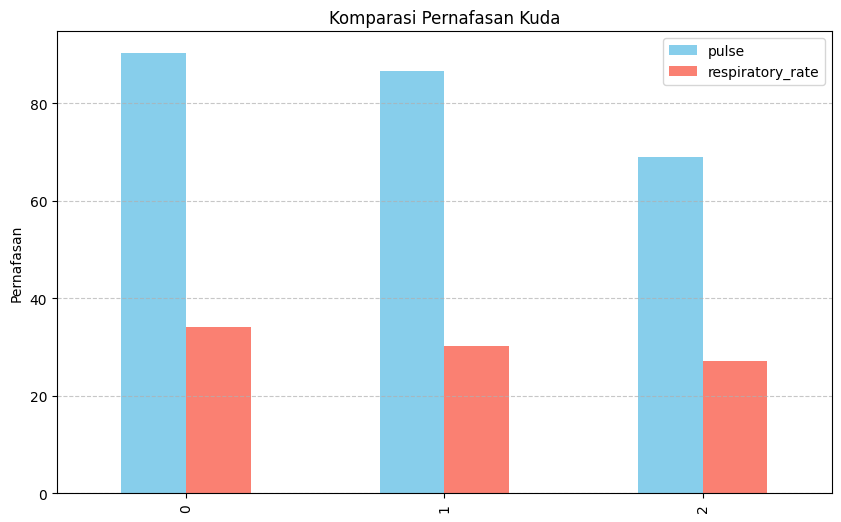

In [226]:
pulse_stats = df_train_clean_map.groupby('outcome')[['pulse', 'respiratory_rate']].mean().reset_index(drop=True)

print('========= Rata-Rata Pernafasan Kuda ==========')
print(pulse_stats)

pulse_stats.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Komparasi Pernafasan Kuda')
plt.ylabel('Pernafasan')
plt.xticks(rotation = 90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## F.GUI

### F.1 Mencari Fitur Paling Berpengaruh Untuk GUI

In [227]:
correlation = df_train_clean_map.corr()['outcome'].abs().sort_values(ascending=False)
print(correlation.head(10))


outcome                  1.000000
abdomo_appearance        0.341097
pulse                    0.330282
capillary_refill_time    0.283691
surgical_lesion          0.262132
temp_of_extremities      0.246979
packed_cell_volume       0.235642
peripheral_pulse         0.230031
respiratory_rate         0.185242
age                      0.176527
Name: outcome, dtype: float64
